<a href="https://colab.research.google.com/github/01l01/Tensorflow/blob/main/Predict_closed_SoF_questions_reBERTa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Note: We need GPU to train our data, enable it from settings before presenting in Class!!!!!

!nvidia-smi

Tue Dec 16 17:42:36 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             51W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf
import keras_nlp
import os
from google.colab import drive

# 1. Mount Drive (to access the saved model)
drive.mount('/content/drive')

# # 2. Re-set the legacy Keras environment variable (if you used it during saving)
# os.environ['TF_USE_LEGACY_KERAS'] = '1'

Mounted at /content/drive


In [3]:
# !pip uninstall -y tensorflow tensorflow-text tensorflow-hub tf-keras

# !pip install tensorflow==2.19.0 tensorflow-text==2.19.0 tensorflow-hub==0.16.1 tf-keras==2.19.0

# import os
# os.kill(os.getpid(), 9)

In [4]:
import tensorflow_text as text

In [5]:
# necessary imports -->
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub
import os


In [6]:
csv_path = "/content/drive/MyDrive/latest_output_english.csv"
print("Using CSV:", csv_path)

df = pd.read_csv(csv_path)
df.shape


Using CSV: /content/drive/MyDrive/latest_output_english.csv


(20850, 8)

In [7]:
# sample from dataset
df.tail(5)

,Title,BodyMarkdown,Tag1,Tag2,Tag3,Tag4,Tag5,OpenStatus
20845,I want validation on textbox for phone number,I want validation on text box for phone number...,javascript,jquery,html,regex,NaN,not a real question
20846,Recommend web server book,I'm looking for an up-to-date book which prese...,books,web,NaN,NaN,NaN,not constructive
20847,ASP.NET development without internet connection,How do I configure Visual Studio 2010 such tha...,asp.net,NaN,NaN,NaN,NaN,open
20848,Student programming for Android. Having proble...,I am programming an assignment and I need to f...,php,android,database,sqlite,android-database,open
20849,J2ME UI Frameworks,I would like to know your opinion about the be...,user-interface,frameworks,java-me,NaN,NaN,not constructive


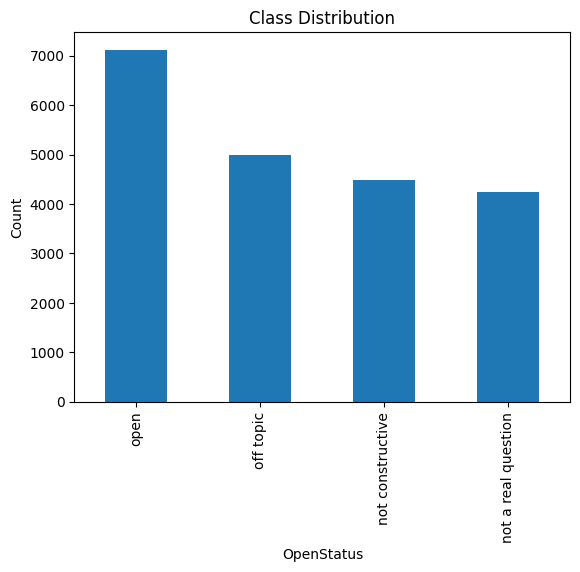

In [8]:
import matplotlib.pyplot as plt
"""
Here we have 4 different question status :
1. Open
2. not real question
3. off topic
4. not constructive
"""
df['OpenStatus'].value_counts().plot(kind='bar', title='Class Distribution')
plt.xlabel('OpenStatus')
plt.ylabel('Count')
plt.show()

In [9]:
# statistics fro each status -> (number of questions)

class_distribution = df['OpenStatus'].value_counts()
print(class_distribution)

OpenStatus
open                   7116
off topic              4994
not constructive       4493
not a real question    4247
Name: count, dtype: int64


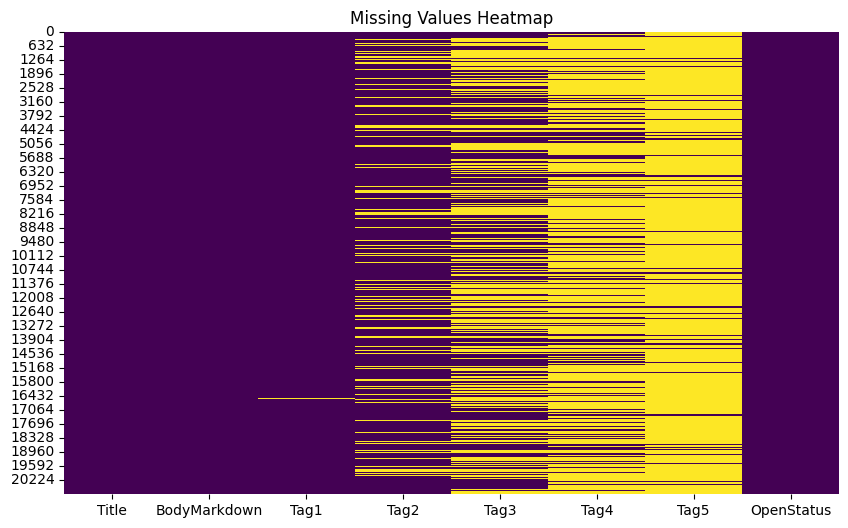

In [10]:
import seaborn as sns

# check missing values before we start training ..
# ofc all missing values related to tags and thats totally fine for us
missing_values = df.isnull()

plt.figure(figsize=(10, 6))
sns.heatmap(missing_values, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split


#  train, validation and test splitting  (70%,20% ,10%)
train_df, remaining = train_test_split(df, random_state=42, train_size=0.7, stratify=df.OpenStatus.values)
valid_df, test_df = train_test_split(remaining, random_state=42, train_size=0.6667, stratify=remaining.OpenStatus.values)


train_df.shape, valid_df.shape, test_df.shape

((14594, 8), (4170, 8), (2086, 8))

In [12]:
# only for training dataset
class_distribution = train_df['OpenStatus'].value_counts()
print(class_distribution)

OpenStatus
open                   4981
off topic              3495
not constructive       3145
not a real question    2973
Name: count, dtype: int64


In [13]:
train_df.shape

(14594, 8)

In [14]:
# Checking the number of samples from each class of train_df

class_distribution = train_df['OpenStatus'].value_counts()
print(class_distribution)

OpenStatus
open                   4981
off topic              3495
not constructive       3145
not a real question    2973
Name: count, dtype: int64


In [15]:
train_df.tail(5)

,Title,BodyMarkdown,Tag1,Tag2,Tag3,Tag4,Tag5,OpenStatus
6755,How to write a batch file that will open a pro...,At work we need to login to pidgin (the mozill...,batch-file,NaN,NaN,NaN,NaN,off topic
7725,Lisp Sample Code Requirement,"I want some sample code like merging 2 lists ,...",lisp,schema,prolog,clisp,NaN,not a real question
3624,Importing IIF files to Quickbooks for purchase...,Importing IIF files to Quickbooks for purchase...,quickbooks,NaN,NaN,NaN,NaN,open
8752,Thorough Sharepoint 2010 development books tha...,I'm looking for a developer's book that would ...,books,sharepoint2010,NaN,NaN,NaN,not constructive
12700,What's less safe?,SQLDatabase or Source code from ASP.NET applic...,asp.net,hacking,NaN,NaN,NaN,not a real question


In [16]:
# comibne title, tags and BodyMarkdown to create a SINGLE text input (:

for index, row in train_df.iterrows():
    text = "Title: " + "'" + row.Title + "'"
    # text += " Tags: {" + ', '.join(str(tag) for tag in [row.Tag1, row.Tag2, row.Tag3, row.Tag4, row.Tag5] if not pd.isnull(tag)) + "}"
    text += "  Body: " + "'" + row.BodyMarkdown + "'"
    train_df.at[index, 'text'] = text


for index, row in valid_df.iterrows():
    text = "Title: " + "'" + row.Title + "'"
    # text += " Tags: {" + ', '.join(str(tag) for tag in [row.Tag1, row.Tag2, row.Tag3, row.Tag4, row.Tag5] if not pd.isnull(tag)) + "}"
    text += "  Body: " + "'" + row.BodyMarkdown + "'"
    valid_df.at[index, 'text'] = text

for index, row in test_df.iterrows():
    text = "Title: " + "'" + row.Title + "'"
    # text += " Tags: {" + ', '.join(str(tag) for tag in [row.Tag1, row.Tag2, row.Tag3, row.Tag4, row.Tag5] if not pd.isnull(tag)) + "}"
    text += "  Body: " + "'" + row.BodyMarkdown + "'"
    test_df.at[index, 'text'] = text

In [17]:
train_df.tail(5)

,Title,BodyMarkdown,Tag1,Tag2,Tag3,Tag4,Tag5,OpenStatus,text
6755,How to write a batch file that will open a pro...,At work we need to login to pidgin (the mozill...,batch-file,NaN,NaN,NaN,NaN,off topic,Title: 'How to write a batch file that will op...
7725,Lisp Sample Code Requirement,"I want some sample code like merging 2 lists ,...",lisp,schema,prolog,clisp,NaN,not a real question,Title: 'Lisp Sample Code Requirement' Body: '...
3624,Importing IIF files to Quickbooks for purchase...,Importing IIF files to Quickbooks for purchase...,quickbooks,NaN,NaN,NaN,NaN,open,Title: 'Importing IIF files to Quickbooks for ...
8752,Thorough Sharepoint 2010 development books tha...,I'm looking for a developer's book that would ...,books,sharepoint2010,NaN,NaN,NaN,not constructive,Title: 'Thorough Sharepoint 2010 development b...
12700,What's less safe?,SQLDatabase or Source code from ASP.NET applic...,asp.net,hacking,NaN,NaN,NaN,not a real question,Title: 'What's less safe?' Body: 'SQLDatabase...


In [18]:
columns_to_drop = ['Title', 'BodyMarkdown']
train_df.drop(columns=columns_to_drop, inplace=True)
valid_df.drop(columns=columns_to_drop, inplace=True)
test_df.drop(columns=columns_to_drop, inplace=True)

In [19]:
train_df.tail(5)

,Tag1,Tag2,Tag3,Tag4,Tag5,OpenStatus,text
6755,batch-file,NaN,NaN,NaN,NaN,off topic,Title: 'How to write a batch file that will op...
7725,lisp,schema,prolog,clisp,NaN,not a real question,Title: 'Lisp Sample Code Requirement' Body: '...
3624,quickbooks,NaN,NaN,NaN,NaN,open,Title: 'Importing IIF files to Quickbooks for ...
8752,books,sharepoint2010,NaN,NaN,NaN,not constructive,Title: 'Thorough Sharepoint 2010 development b...
12700,asp.net,hacking,NaN,NaN,NaN,not a real question,Title: 'What's less safe?' Body: 'SQLDatabase...


In [20]:
# Example :::
for index, row in train_df.iterrows():
    print("Text: ")
    print("________________________")
    print(row.text, end='\n\n\n\n')
    print("Target Class:")
    print("________________________")
    print(row.OpenStatus)
    break

Text: 
________________________
Title: 'Java based OCR SDK/API'  Body: 'Are there any good OCR (optical character recognition) SDK or APIs in Java which will be able to convert TIFF files to txt files (or even html is good enough) with some sort of format retention ? The challenge is to read a typical news magazine article and know that it has a header and certain number of paragraphs and pictures.

I am Ok with looking at the commercial and open source SDKs/APIs. Any help is appreciated.'



Target Class:
________________________
not constructive


In [21]:
# Definelabel mapping
custom_label_mapping = {'open': 0,
                        'not a real question': 1,
                        'off topic': 2,
                        'not constructive':3
                        }

# Initialize LabelEncoder with custom mapping
encoded_labels = []
for index, row in train_df.iterrows():
    label = row['OpenStatus']
    encoded_label = custom_label_mapping[label]
    encoded_labels.append(encoded_label)

# Add the encoded labels as a new column in the DataFrame
train_df['OpenStatus_encoded'] = encoded_labels



# Applying the same changes to valid_df and test_df
encoded_labels = []
for index, row in valid_df.iterrows():
    label = row['OpenStatus']
    encoded_label = custom_label_mapping[label]
    encoded_labels.append(encoded_label)

# Add the encoded labels as a new column in the DataFrame
valid_df['OpenStatus_encoded'] = encoded_labels



encoded_labels = []
for index, row in test_df.iterrows():
    label = row['OpenStatus']
    encoded_label = custom_label_mapping[label]
    encoded_labels.append(encoded_label)

# Add the encoded labels as a new column in the DataFrame
test_df['OpenStatus_encoded'] = encoded_labels

In [22]:
train_df.tail(5)

,Tag1,Tag2,Tag3,Tag4,Tag5,OpenStatus,text,OpenStatus_encoded
6755,batch-file,NaN,NaN,NaN,NaN,off topic,Title: 'How to write a batch file that will op...,2
7725,lisp,schema,prolog,clisp,NaN,not a real question,Title: 'Lisp Sample Code Requirement' Body: '...,1
3624,quickbooks,NaN,NaN,NaN,NaN,open,Title: 'Importing IIF files to Quickbooks for ...,0
8752,books,sharepoint2010,NaN,NaN,NaN,not constructive,Title: 'Thorough Sharepoint 2010 development b...,3
12700,asp.net,hacking,NaN,NaN,NaN,not a real question,Title: 'What's less safe?' Body: 'SQLDatabase...,1


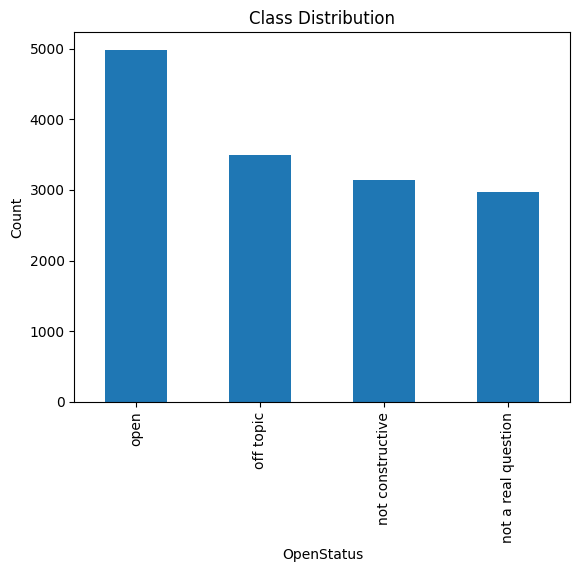

In [23]:
train_df['OpenStatus'].value_counts().plot(kind='bar', title='Class Distribution')
plt.xlabel('OpenStatus')
plt.ylabel('Count')
plt.show()

In [24]:
X_train = train_df["text"]
y_train = train_df["OpenStatus_encoded"]

X_valid = valid_df["text"]
y_valid = valid_df["OpenStatus_encoded"]

X_test = test_df["text"]
y_test = test_df["OpenStatus_encoded"]

In [25]:
print(X_train.shape)
print(y_train.shape)

print(X_valid.shape)
print(y_valid.shape)

print(X_test.shape)
print(y_test.shape)

(14594,)
(14594,)
(4170,)
(4170,)
(2086,)
(2086,)


In [26]:

!pip install keras-nlp

In [27]:
import os
import random
import numpy as np
import tensorflow as tf
import keras_nlp
from tensorflow.keras.layers import Input, Dropout, BatchNormalization, Dense
from tensorflow.keras import Model, regularizers

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

text_input = tf.keras.Input(shape=(), dtype=tf.string)

preprocessor = keras_nlp.models.RobertaPreprocessor.from_preset(
    "roberta_base_en",
    sequence_length=256
)

encoder_inputs = preprocessor(text_input)

encoder = keras_nlp.models.RobertaBackbone.from_preset(
    "roberta_base_en"
)

sequence_output = encoder(encoder_inputs)

# CLS token pooling (RoBERTa style)
pooled_output = sequence_output[:, 0, :]





x = Dropout(0.3)(pooled_output)
x = Dense(128, activation="relu")(x)

output_layer = Dense(
    4,
    activation="softmax",
    name="output"
)(x)

model = Model(inputs=text_input, outputs=output_layer)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=2e-6),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roberta_text_class… │ [(None, 256),     │          0 │ input_layer[0][0] │
│ (RobertaTextClassi… │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roberta_backbone    │ (None, 256, 768)  │ 124,052,7… │ roberta_text_cla… │
│ (RobertaBackbone)   │                   │            │ roberta_text_cla… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 768)       │          0 │ roberta_backbone… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 768)       │          0 │ get_item[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     98,432 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │        516 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 124,151,684 (473.60 MB)

 Trainable params: 124,151,684 (473.60 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Define callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
       filepath='best_model.weights.h5',
        save_best_only=True,
        monitor='val_accuracy',
        save_weights_only=True,
        verbose=1,
        save_freq='epoch'
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=3,
        monitor='val_accuracy',
        restore_best_weights=True
    ),
     tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=5e-6
    )
]

In [29]:
print(f"X_train Shape: {X_train.shape}, Dtype: {X_train.dtype}")
print(f"y_train Shape: {y_train.shape}, Dtype: {y_train.dtype}")
print(f"X_valid Shape: {X_valid.shape}, Dtype: {X_valid.dtype}")
print(f"y_valid Shape: {y_valid.shape}, Dtype: {y_valid.dtype}")

X_train Shape: (14594,), Dtype: object
y_train Shape: (14594,), Dtype: int64
X_valid Shape: (4170,), Dtype: object
y_valid Shape: (4170,), Dtype: int64


In [30]:
#conver X_train to String
X_train = X_train.astype("string")
X_valid = X_valid.astype("string")

In [31]:
X_train

,text
8205,Title: 'Java based OCR SDK/API' Body: 'Are th...
9441,"Title: 'VIM: Delete+Paste in one ""command""?' ..."
10625,Title: 'What Charting API / Tool is this?' Bo...
10589,Title: 'Highly Innovative Software Library?' ...
632,Title: 'working in excel for formula calculati...
...,...
6755,Title: 'How to write a batch file that will op...
7725,Title: 'Lisp Sample Code Requirement' Body: '...
3624,Title: 'Importing IIF files to Quickbooks for ...
8752,Title: 'Thorough Sharepoint 2010 development b...


In [32]:
train_df['OpenStatus'].value_counts()


,count
OpenStatus,
open,4981
off topic,3495
not constructive,3145
not a real question,2973


In [33]:
# BERT models usually perform best with a small batch size.
BATCH_SIZE = 16

epochs = 10

from sklearn.utils.class_weight import compute_class_weight
unique_classes = np.unique(y_train)
class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)
class_weight = {int(c): float(w) for c, w in zip(unique_classes, class_weights_values)}
print("Class weights:", class_weight)

# Re-compile the model with jit_compile=False to avoid XLA issues with string inputs
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=2e-6),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
    jit_compile=False # Disable JIT compilation to avoid issues with string inputs on XLA
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=epochs,
    verbose=1,
    callbacks=callbacks,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
)

Class weights: {0: 0.7324834370608312, 1: 1.2272115708039018, 2: 1.0439198855507867, 3: 1.1600953895071542}
Epoch 1/10
913/913 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.4130 - loss: 1.3037
Epoch 1: val_accuracy improved from -inf to 0.66619, saving model to best_model.weights.h5
913/913 ━━━━━━━━━━━━━━━━━━━━ 215s 172ms/step - accuracy: 0.4132 - loss: 1.3035 - val_accuracy: 0.6662 - val_loss: 0.8511 - learning_rate: 2.0000e-06
Epoch 2/10
913/913 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6688 - loss: 0.8588
Epoch 2: val_accuracy improved from 0.66619 to 0.71583, saving model to best_model.weights.h5
913/913 ━━━━━━━━━━━━━━━━━━━━ 137s 150ms/step - accuracy: 0.6688 - loss: 0.8588 - val_accuracy: 0.7158 - val_loss: 0.7367 - learning_rate: 2.0000e-06
Epoch 3/10
913/913 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7248 - loss: 0.7252
Epoch 3: val_accuracy improved from 0.71583 to 0.75947, saving model to best_model.weights.h5
913/913 ━━━━━━━━━━━━━━━━━━━━ 137s 150ms/step - accu

In [34]:
from sklearn.metrics import f1_score
import numpy as np

y_pred = model.predict(np.array(X_valid.tolist(), dtype=object))
y_pred = np.argmax(y_pred, axis=1)

macro_f1 = f1_score(y_valid, y_pred, average="macro")
print("Macro F1:", macro_f1)

131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 154ms/step
Macro F1: 0.9210578322899076


In [41]:
to_class_map = {0 : 'open',
                      1 : 'not a real question',
                      2 : 'off topic',
                3:'not constructive'
                }
label_to_class_map = {0 : 'open',
                      1 : 'not a real question',
                      2 : 'off topic',
                       3:'not constructive'
                      }
categories = ['open',
              'not a real question',
              'off topic',
              'not constructive'
             ]

In [37]:
X_test.shape
X_test.tolist()[:2]

["Title: 'portable usb lamp server that runs on linux'  Body: 'ive found some portable lamp servers like xampp lite but i cant found one that runs on linux, all they are for windows\r\ni need only a lamp server, not a virtual image of a linux system..., i want to run web applications from the usb.'",
 "Title: 'sizeof() structures not known. Why?'  Body: 'Why can't I use sizeof() on simple structs?\r\n\r\neg:\r\n\r\n    private struct FloatShortPair\r\n    {\r\n        public float myFloat;\r\n        public short myShort;\r\n    };\r\n    \r\n    int size = sizeof(FloatShortPair);  //CS0233\r\n\r\n\r\n**error CS0233: 'FloatShortPair' does not have a predefined size, therefore sizeof can only be used in an unsafe context (consider using System.Runtime.InteropServices.Marshal.SizeOf)**\r\n\r\n\r\n[MSDN][1] states: \r\n\r\n> The sizeof operator can only be used for types that are compile-time\r\n> constants. If you are getting this error, make sure that the size of\r\n> the identifier can

In [38]:

save_path = '/content/drive/MyDrive/sof_classifier_model_vFinal_v2_reBERTa.keras'

model.save(save_path)

print(f"Model saved successfully to: {save_path}")

Model saved successfully to: /content/drive/MyDrive/sof_classifier_model_vFinal_v2_reBERTa.keras


In [ ]:
model = tf.keras.models.load_model('/content/drive/MyDrive/sof_classifier_model_vFinal_v2_reBERTa.keras')

___________________________________________________


TEXT:


Title: 'Scala ecosystems compared to Ruby on Rails'  Body: 'I'm RoR developer, considering to migrate to Scala + Plays/Lift framework.

My main considering is the ecosystem. Does Scala currently have as rich libraries as RoR? If not, what kind of critical-libraries and nice-to-have-libraries are missed?'



___________________________________________________


GROUND TRUTH:


not constructive



___________________________________________________



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


PREDICTION:




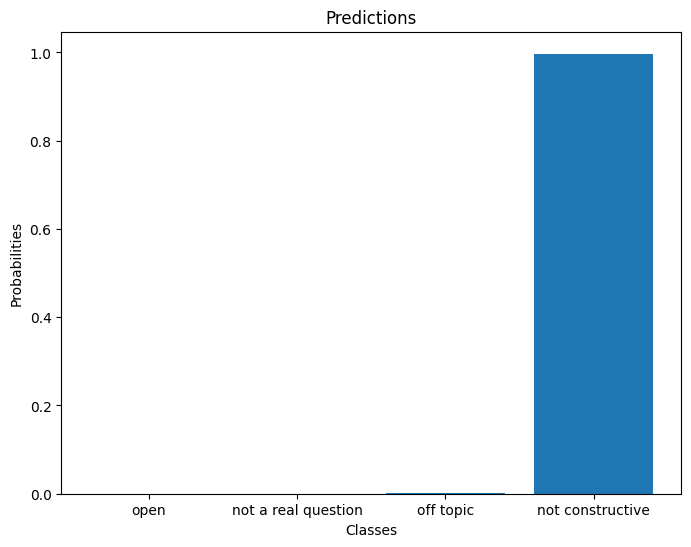




___________________________________________________


PREDICTED CLASS:  not constructive



___________________________________________________



CORRECT PREDICTION !!!


In [53]:
import random
import numpy as np

X_test_list = X_test.tolist()
y_test_list = y_test.tolist()

rand_int = random.randint(0, len(X_test_list) - 1)

text_to_predict = X_test_list[rand_int]

print("___________________________________________________")
print("\n\nTEXT:\n\n")
print(text_to_predict)
print("\n\n")
print("___________________________________________________")
print("\n\nGROUND TRUTH:\n\n")
print(label_to_class_map[y_test_list[rand_int]])
print("\n\n")
print("___________________________________________________")


print("\n\n")

input_for_prediction = np.array([text_to_predict], dtype=object)
prediction = model.predict(input_for_prediction)

print("\n\nPREDICTION:\n\n")


plt.figure(figsize=(8, 6))
plt.bar(categories, prediction[0])
plt.xlabel('Classes')
plt.ylabel('Probabilities')
plt.title('Predictions')
plt.show()
print("\n\n")
print("___________________________________________________")



predicted_class_index = np.argmax(prediction)
print("\n\nPREDICTED CLASS: ", label_to_class_map[predicted_class_index])
print('\n\n')
print("___________________________________________________")



print("\n\n")
if label_to_class_map[predicted_class_index] == label_to_class_map[y_test_list[rand_int]]:
    print("CORRECT PREDICTION !!!")
else:
    print("WRONG PREDICTION !!!")

___________________________________________________


TEXT TO PREDICT:


Title: '' Body: ''



___________________________________________________
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


PREDICTION PROBABILITIES:




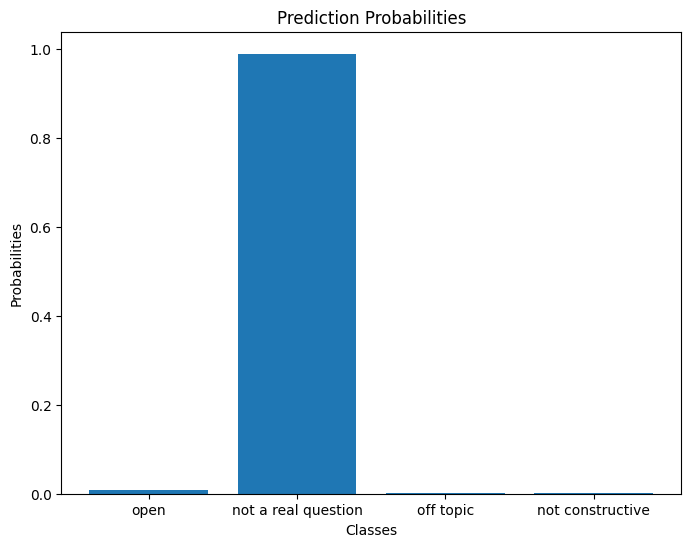




___________________________________________________


PREDICTED CLASS:  not a real question



___________________________________________________


In [52]:
import numpy as np
import matplotlib.pyplot as plt

my_title = ""
my_body = """"""

text_to_predict = "Title: '" + my_title + "' Body: '" + my_body + "'"

print("___________________________________________________")
print("\n\nTEXT TO PREDICT:\n\n")
print(text_to_predict)
print("\n\n")
print("___________________________________________________")

# Prepare the input for the model
input_for_prediction = np.array([text_to_predict], dtype=object)

# Get the prediction from the model
prediction = model.predict(input_for_prediction)

print("\n\nPREDICTION PROBABILITIES:\n\n")


plt.figure(figsize=(8, 6))
plt.bar(categories, prediction[0])
plt.xlabel('Classes')
plt.ylabel('Probabilities')
plt.title('Prediction Probabilities')
plt.show() # Renders the chart
print("\n\n")
print("___________________________________________________")

# Get the predicted class
predicted_class_index = np.argmax(prediction)
print("\n\nPREDICTED CLASS: ", label_to_class_map[predicted_class_index])
print('\n\n')
print("___________________________________________________")

___________________________________________________


TEXT:


Title: 'Which platform should I use to code a mobile application?'  Body: 'I want to code a mobile application and need some guidance. I want to code an application that can do the following;

1. Take a picture.
2. Split the picture into 9 tiles
3. Randomly place the tiles on the screen.
4. Have the user unscramble the picture.

Now I don't know anything about mobile coding yet. So I would like to know form anyone who does, what is the best platform/framework to code this in and also is there an easy way to have this work on both iphone/ipod touch and android?

Thanks for any suggestion and guidance you can give me.
'



___________________________________________________


GROUND TRUTH:


not constructive



___________________________________________________



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


PREDICTION:




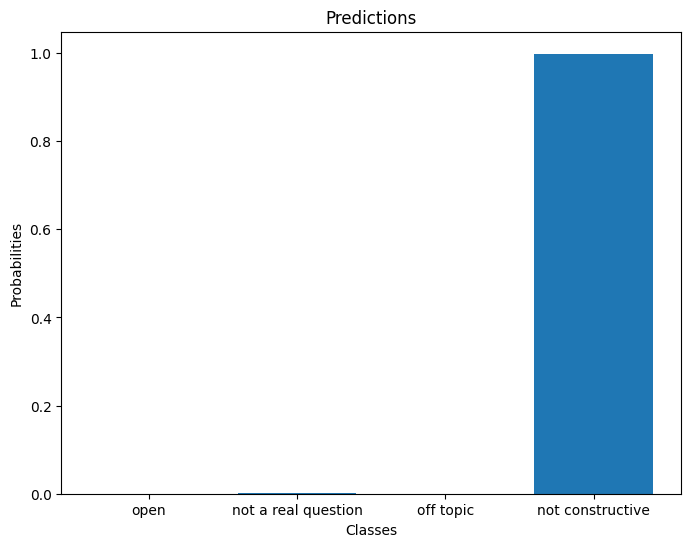




___________________________________________________


PREDICTED CLASS:  not constructive



___________________________________________________



CORRECT PREDICTION !!!


In [45]:

X_test_list = X_test.tolist()
y_test_list = y_test.tolist()

rand_int = random.randint(0, len(X_test_list) - 1)

text_to_predict = X_test_list[rand_int]

print("___________________________________________________")
print("\n\nTEXT:\n\n")
print(text_to_predict)
print("\n\n")
print("___________________________________________________")
print("\n\nGROUND TRUTH:\n\n")
print(label_to_class_map[y_test_list[rand_int]])
print("\n\n")
print("___________________________________________________")


print("\n\n")

input_for_prediction = np.array([text_to_predict], dtype=object)
prediction = model.predict(input_for_prediction) # Pass the NumPy array

print("\n\nPREDICTION:\n\n")


plt.figure(figsize=(8, 6))
plt.bar(categories, prediction[0])
plt.xlabel('Classes')
plt.ylabel('Probabilities')
plt.title('Predictions')
plt.show() # Renders the chart
print("\n\n")
print("___________________________________________________")



predicted_class_index = np.argmax(prediction)
print("\n\nPREDICTED CLASS: ", label_to_class_map[predicted_class_index])
print('\n\n')
print("___________________________________________________")



print("\n\n")
if label_to_class_map[predicted_class_index] == label_to_class_map[y_test_list[rand_int]]:
    print("CORRECT PREDICTION !!!")
else:
    print("WRONG PREDICTION !!!")

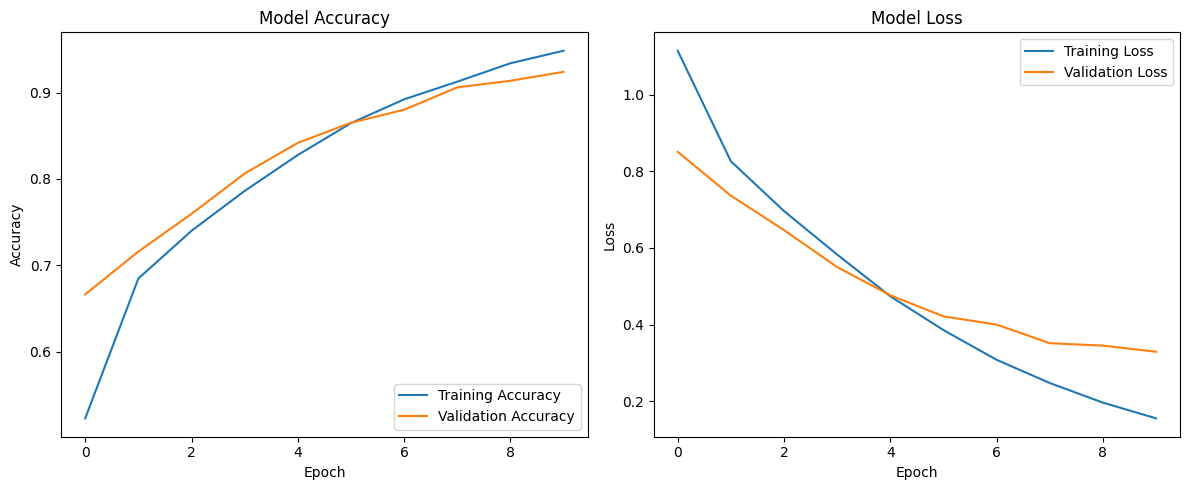

In [46]:
import matplotlib.pyplot as plt

# 1. Extract training and validation accuracy and loss
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(accuracy))

# 2. Create a figure with two subplots
plt.figure(figsize=(12, 5))

# Plot training and validation accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training and validation loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# 3. Adjust layout and display plots
plt.tight_layout()
plt.show()


66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step


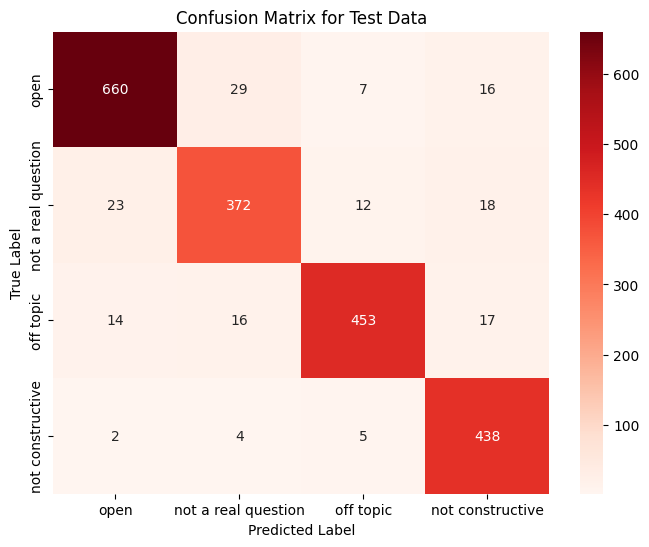

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Make predictions on the test data
X_test_array = np.array(X_test.tolist(), dtype=object) # Ensure X_test is an array of objects
y_pred_probabilities = model.predict(X_test_array)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# 2. Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Define class names for plotting
class_names = [label_to_class_map[i] for i in sorted(label_to_class_map.keys())]

# 4. Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Test Data')
plt.show()



1. Tried with batch size 16 and 2 norms val_accurace was awful recompiled on batcgsize 32 and removed the second norm
2. Tried with batch size 32 (second norm removed), dropout 0.3 max val_accuracy gained is 0.68311, train accuracy about 0.92 clearly there is an overfitting happening. Trying again after increasing dropout to 0.5, dense 64
3. After making this changes above the val_accuracy increased to 0.70777. still not ideal yeah ?! Trying to shrink sequence_length from 128 to 64 let's see ?! Hmm the result is more worth now its about 0.67 again.